In [ ]:
import torch
from torch import Tensor, nn
from typing import Dict, Optional
from math import ceil
import numpy as np
from torch.autograd import Function
import os
from torch.autograd.function import Function
from functools import partial
import math
import triton
from copy import deepcopy
import triton.language as tl
from triton.tools.tensor_descriptor import TensorDescriptor

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [ ]:
os.environ["TRITON_PRINT_AUTOTUNING"] = "1"

In [ ]:
from triton_kernels.nn.gated_mlp.ops.bwd import mlp_hidden_states_bwd as bwd_op_triton
from triton_kernels.nn.gated_mlp.gated_mlp import (
    ACT_FWD,
)

In [ ]:
import triton
import triton.language as tl
import torch
from torch import Tensor
from typing import Tuple, Optional
import math

from triton_kernels.nn.gated_mlp.ops.utils import get_num_streaming_multiprocessors, map_pid_m_n
from triton_kernels.nn.gated_mlp.ops.act import _act_bwd, _act_fwd
from triton_kernels.utils import get_device


def _matmul_launch_metadata(grid, kernel, args):
    ret = {}
    M, N, K, WS = args["M"], args["N"], args["K"], args.get("WARP_SPECIALIZE", False)
    ws_str = "_ws" if WS else ""
    ret["name"] = f"{kernel.name}{ws_str} [M={M}, N={N}, K={K}]"
    if "c_ptr" in args:
        bytes_per_elem = args["c_ptr"].element_size()
    else:
        bytes_per_elem = 1 if args["FP8_OUTPUT"] else 2
    ret[f"flops{bytes_per_elem * 8}"] = 2. * M * N * K
    ret["bytes"] = bytes_per_elem * (M * K + N * K + M * N)
    return ret


def get_autotune_configs(pre_hook=None):
    return [
        triton.Config(
            {
                'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, 
            }, pre_hook=pre_hook)  #
        for BM in [32, 64, 128]  #
        for BN in [32, 64, 128]  #
        for BK in [32, 64, 128]  #
        for GS in [4, 8]  #
        # for s in ([2])  #
        # for w in [4]  #
        # for SUBTILE in [True, False]  #
    ]

@triton.autotune(
    configs=get_autotune_configs(), 
    key=["M", "N", "K"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def _compute_quantities_for_bwd(
    x_ptr,
    W_up_ptr,
    W_gp_ptr,
    grad_output_ptr,
    act_prime_ptr,
    grad_output_a_act_prime_ptr,
    grad_output_c_ptr,
    act_fun: tl.constexpr,
    M,
    N,
    K,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    """
    Kernel for computing:

        a = x @ W_up.T
        b = x @ W_gp.T
        c = act_fwd(b)

        sigma = torch.sigmoid(b)
        act_prime = sigma * (1 + b * (1 - sigma))

        grad_output_a_act_prime = (grad_output * a) * act_prime
        grad_output_c = grad_output * c
    """
    pid = tl.program_id(axis=0)
    num_programs_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_total_programs = num_programs_m * num_programs_n

    ### create tensor desctiptors (inputs)
    x_desc = tl.make_tensor_descriptor(
        x_ptr,
        shape=[M, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K],
    )
    W_up_desc = tl.make_tensor_descriptor(
        W_up_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )
    W_gp_desc = tl.make_tensor_descriptor(
        W_gp_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )
    grad_output_desc = tl.make_tensor_descriptor(
        grad_output_ptr,
        shape=[M, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
    )

    ### create tensor desctiptors (outputs)
    act_prime_desc = tl.make_tensor_descriptor(
        act_prime_ptr,
        shape=[M, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
    )
    grad_output_a_act_prime_desc = tl.make_tensor_descriptor(
        grad_output_a_act_prime_ptr,
        shape=[M, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
    )
    grad_output_c_desc = tl.make_tensor_descriptor(
        grad_output_c_ptr,
        shape=[M, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
    )

    ### loop along M
    for tile_id in tl.range(pid, num_total_programs, NUM_SMS):
        pid_m, pid_n = map_pid_m_n(
            tile_id, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, True
        )

        offset_m = pid_m * BLOCK_SIZE_M
        offset_n = pid_n * BLOCK_SIZE_N

        tile_a = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        tile_b = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

        ### loop along K
        for offset_k in tl.range(0, K, BLOCK_SIZE_K):
            # NOTE: masking along k is done under the hood by tensor descriptors
            # offset_k = k * BLOCK_SIZE_K

            tile_x = x_desc.load([offset_m, offset_k])
            tile_W_up = W_up_desc.load([offset_n, offset_k])
            tile_W_gp = W_gp_desc.load([offset_n, offset_k])

            tile_a = tl.dot(tile_x, tile_W_up.T, acc=tile_a)
            tile_b = tl.dot(tile_x, tile_W_gp.T, acc=tile_b)

        tile_c = _act_fwd(tile_b, act_fun)
        tile_act_prime = _act_bwd(tile_b, act_fun)

        # grad_output_a_act_prime = (grad_output * a) * act_prime
        tile_grad_output = grad_output_desc.load([offset_m, offset_n])
        tile_grad_output_a_act_prime = (tile_grad_output * tile_a) * tile_act_prime

        # grad_output_c = grad_output * c
        tile_grad_output_c = tile_grad_output * tile_c

        ### store results back in memory
        offsets = [offset_m, offset_n]
        act_prime_desc.store(offsets=offsets, value=tile_act_prime)
        grad_output_a_act_prime_desc.store(
            offsets=offsets, value=tile_grad_output_a_act_prime
        )
        grad_output_c_desc.store(offsets=offsets, value=tile_grad_output_c)


@triton.autotune(
    configs=get_autotune_configs(), 
    key=["M", "N", "K"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def _compute_dx(
    grad_output_c_ptr,
    W_up_ptr,
    grad_output_a_act_prime_ptr,
    W_gp_ptr,
    dx_ptr,
    M,
    N,
    K,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    """
    Triton kernel computing:
        
        dx_1 = grad_output_c @ W_up
        dx_2 = grad_output_a_act_prime @ W_gp
        dx = dx_1 + dx_2

    """
    pid = tl.program_id(axis=0)
    num_programs_m = tl.cdiv(M, BLOCK_SIZE_M)
    # num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_programs_k = tl.cdiv(K, BLOCK_SIZE_K)
    num_programs = num_programs_m * num_programs_k

    ### tensor descriptors of inputs
    grad_output_c_desc = tl.make_tensor_descriptor(
        grad_output_c_ptr,
        shape=[M, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N],
    )
    W_up_desc = tl.make_tensor_descriptor(
        W_up_ptr, shape=[N, K], strides=[K, 1], block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K]
    )
    grad_output_a_act_prime_desc = tl.make_tensor_descriptor(
        grad_output_a_act_prime_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N]
    )
    W_gp_desc = tl.make_tensor_descriptor(
        W_gp_ptr, shape=[N, K], strides=[K, 1], block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K]
    )

    ### tensor descriptor of output
    dx_desc = tl.make_tensor_descriptor(
        dx_ptr, shape=[M, K], strides=[K, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    )

    for tile_id in tl.range(pid, num_programs, NUM_SMS):
        pid_m, pid_k = map_pid_m_n(
            tile_id, M, K, BLOCK_SIZE_M, BLOCK_SIZE_K, GROUP_SIZE_M, True
        )

        offset_m = pid_m * BLOCK_SIZE_M
        offset_k = pid_k * BLOCK_SIZE_K

        tile_dx_1 = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_K), dtype=tl.float32)
        tile_dx_2 = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_K), dtype=tl.float32)

        for offset_n in tl.range(0, N, BLOCK_SIZE_N):

            tile_grad_output_c = grad_output_c_desc.load([offset_m, offset_n])
            tile_W_up = W_up_desc.load([offset_n, offset_k])
            tile_dx_1 = tl.dot(tile_grad_output_c, tile_W_up, acc=tile_dx_1)

            tile_grad_output_a_act_prime = grad_output_a_act_prime_desc.load(
                [offset_m, offset_n]
            )
            tile_W_gp = W_gp_desc.load([offset_n, offset_k])
            tile_dx_2 = tl.dot(tile_grad_output_a_act_prime, tile_W_gp, acc=tile_dx_2)

        tile_dx = tile_dx_1 + tile_dx_2

        ### store back in memory
        dx_desc.store([offset_m, offset_k], tile_dx)



@triton.autotune(
    configs=get_autotune_configs(), 
    key=["M", "N", "K"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def _compute_dW_up_dW_gp(
        x_ptr, grad_output_c_ptr, grad_output_a_act_prime_ptr, dW_up_ptr, dW_gp_ptr,
        M,
        N,
        K,
        NUM_SMS : tl.constexpr,
        BLOCK_SIZE_M : tl.constexpr,
        BLOCK_SIZE_K : tl.constexpr,
        BLOCK_SIZE_N : tl.constexpr,
        GROUP_SIZE_M : tl.constexpr,
):
    pid = tl.program_id(axis=0)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_programs_k = tl.cdiv(K, BLOCK_SIZE_K)
    num_programs = num_programs_n * num_programs_k

    ### make tensor descriptors inputs
    x_desc = tl.make_tensor_descriptor(
        x_ptr, shape=[M, K], strides=[K, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    )
    grad_output_c_desc = tl.make_tensor_descriptor(
        grad_output_c_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N]
    )
    grad_output_a_act_prime_desc = tl.make_tensor_descriptor(
        grad_output_a_act_prime_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N]
    )

    ### make tensor descriptors outputs
    dW_up_desc = tl.make_tensor_descriptor(
        dW_up_ptr, shape=[N, K], strides=[K, 1], block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K]
    )
    dW_gp_desc = tl.make_tensor_descriptor(
        dW_gp_ptr, shape=[N, K], strides=[K, 1], block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K]
    )

    ### persistent loop
    for tile_id in tl.range(pid, num_programs, NUM_SMS):
        pid_n, pid_k = map_pid_m_n(
            tile_id, N, K, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M, True
        )

        offset_n = pid_n * BLOCK_SIZE_N
        offset_k = pid_k * BLOCK_SIZE_K

        # print(f"{offset_n=}, {offset_k=}")

        tile_dW_up = tl.zeros((BLOCK_SIZE_N, BLOCK_SIZE_K), tl.float32)
        tile_dW_gp = tl.zeros((BLOCK_SIZE_N, BLOCK_SIZE_K), tl.float32)

        for offset_m in tl.range(0, BLOCK_SIZE_M, M):

            tile_grad_output_c = grad_output_c_desc.load([offset_m, offset_n])
            tile_grad_output_a_act_prime = grad_output_a_act_prime_desc.load([offset_m, offset_n])
            tile_x = x_desc.load([offset_m, offset_k])

            tile_dW_up = tl.dot(tile_grad_output_c.T, tile_x, acc=tile_dW_up)
            tile_dW_gp = tl.dot(tile_grad_output_a_act_prime.T, tile_x, acc=tile_dW_gp)

        dW_up_desc.store(offsets=[offset_n, offset_k], value=tile_dW_up)
        dW_gp_desc.store(offsets=[offset_n, offset_k], value=tile_dW_gp)


def mlp_hidden_states_bwd(
    x: Tensor, W_up: Tensor, W_gp: Tensor, grad_output: Tensor
) -> Tuple[Tensor, Tensor, Tensor, Tensor]:

    act_fun = "silu"  # hard-coded for now, parametrize later

    M, K = x.shape
    N, _ = W_gp.shape
    # M = B * M # aready reshaped (B, M, K) -> (B * M, K)

    kwargs = {"device": x.device, "dtype": x.dtype}

    act_prime = torch.zeros((M, N), **kwargs)  # check dtype
    grad_output_a_act_prime = torch.zeros((M, N), **kwargs)  # check dtype
    grad_output_c = torch.zeros((M, N), **kwargs)  # check dtype

    NUM_SMS = get_num_streaming_multiprocessors()
    BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = (64, 64, 64, 8)

    ### provide the allocation function
    def allocation_fn(shape: int, stream: int, alligmnet: Optional[int]):
        return torch.empty(shape, device=x.device, dtype=torch.int8)

    triton.set_allocator(allocation_fn)

    # grid = (min(NUM_SMS, math.ceil(M / BLOCK_SIZE_M) * math.ceil(N / BLOCK_SIZE_N)),)
    grid = lambda META: (min(NUM_SMS, triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), )
    ### compute quantities for bwd
    _compute_quantities_for_bwd[grid](
        x,
        W_up,
        W_gp,
        grad_output,
        act_prime,
        grad_output_a_act_prime,
        grad_output_c,
        act_fun,
        M,
        N,
        K,
        NUM_SMS,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
    )

    """
    # steps to check the results
    a = x @ W_up.T
    b = x @ W_gp.T
    c = ACT_FWD[act_fn](b)
    sigma = torch.sigmoid(b)

    act_prime_ref = sigma * (1 + b * (1 - sigma))
    grad_output_a_act_prime_ref = (grad_output * a) * act_prime
    grad_output_c_ref = grad_output * c

    atol = 1e-3 if "TRITON_INTERPRET" in os.environ.keys() else 1e-7
    triton.testing.assert_close(act_prime, act_prime_ref, atol)
    triton.testing.assert_close(grad_output_a_act_prime, grad_output_a_act_prime_ref, atol)
    triton.testing.assert_close(grad_output_c, grad_output_c_ref, atol)
    """

    ### compute derivatives
    """
    ### dx
    dx_1 = grad_output_c @ W_up
    dx_2 = grad_output_a_act_prime @ W_gp
    dx = dx_1 + dx_2

    ### dW_up
    dW_up = grad_output_c.T @ x

    ### dW_gp
    dW_gp = grad_output_a_act_prime.T @ x
    
    """
    dx = torch.zeros(x.shape, **kwargs)  # .view() already done at higher level
    dW_up = torch.zeros(W_up.shape, **kwargs)  # check dtype
    dW_gp = torch.zeros(W_gp.shape, **kwargs)  # check dtype

    grid = lambda META: (min(NUM_SMS, triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(K, META["BLOCK_SIZE_K"])), )
    grid = (min(NUM_SMS, math.ceil(M / BLOCK_SIZE_M) * math.ceil(K / BLOCK_SIZE_K)),)
    _compute_dx[grid](
        grad_output_c,
        W_up,
        grad_output_a_act_prime,
        W_gp,
        dx,
        M,
        N,
        K,
        NUM_SMS,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_K,
        # BLOCK_SIZE_N,
        # GROUP_SIZE_M,
    )

    grid = lambda META: (min(NUM_SMS, triton.cdiv(K, META["BLOCK_SIZE_K"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), )
    grid = (min(NUM_SMS, math.ceil(K / BLOCK_SIZE_K) * math.ceil(N / BLOCK_SIZE_N)),)
    _compute_dW_up_dW_gp[grid](
        x, grad_output_c, grad_output_a_act_prime, dW_up, dW_gp,
        M,
        N,
        K,
        NUM_SMS,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_K,
        # BLOCK_SIZE_N,
        # GROUP_SIZE_M,
    )

    return dx, dW_up, dW_gp


In [ ]:
def bwd_op_ref(x, W_up, W_gp, grad_output):
    act_fn = "silu"

    a = x @ W_up.T
    b = x @ W_gp.T
    c = ACT_FWD[act_fn](b)
    sigma = torch.sigmoid(b)

    act_prime = sigma * (1 + b * (1 - sigma))
    grad_output_a_act_prime = (grad_output * a) * act_prime
    grad_output_c = grad_output * c

    dx_1 = grad_output_c @ W_up
    dx_2 = grad_output_a_act_prime @ W_gp
    dx = dx_1 + dx_2

    dW_up = grad_output_c.T @ x

    dW_gp = grad_output_a_act_prime.T @ x
    
    return dx, dW_up, dW_gp

provider='torch_eager', DTYPE=torch.float16, M=32, N=32, K=32
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=32, N=32, K=32
provider='torch_eager', DTYPE=torch.float16, M=64, N=64, K=64
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=64, N=64, K=64
provider='torch_eager', DTYPE=torch.float16, M=128, N=128, K=128
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=128, N=128, K=128
provider='torch_eager', DTYPE=torch.float16, M=256, N=256, K=256
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=256, N=256, K=256
provider='torch_eager', DTYPE=torch.float16, M=512, N=512, K=512
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=512, N=512, K=512
provider='torch_eager', DTYPE=torch.float16, M=1024, N=1024, K=1024
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=1024, N=1024, K=1024
provider='torch_eager', DTYPE=torch.float16, M=2048, N=2048, K=2048
provider='mlp_hidden_states_bwd', DTYPE=torch.float16, M=2048, N=2048, K=2048
provider='torch_eage

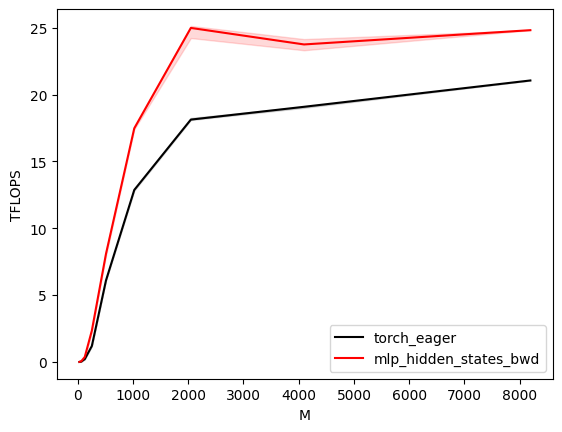

gated-mlp-performance:
        M       N       K  torch_eager  mlp_hidden_states_bwd
0    32.0    32.0    32.0     0.003765               0.007014
1    64.0    64.0    64.0     0.027676               0.051200
2   128.0   128.0   128.0     0.210051               0.372364
3   256.0   256.0   256.0     1.191564               2.340571
4   512.0   512.0   512.0     6.096372               8.081511
5  1024.0  1024.0  1024.0    12.865963              17.476267
6  2048.0  2048.0  2048.0    18.127732              24.984685
7  4096.0  4096.0  4096.0    19.085351              23.749045
8  8192.0  8192.0  8192.0    21.054588              24.816646


In [ ]:
MAP_FUN = {
        "torch_eager": bwd_op_ref,
        # "torch_module" : None, # must be instantiated in the testing function
        "mlp_hidden_states_bwd": mlp_hidden_states_bwd, 
}

matmul_names = list(MAP_FUN.keys())
available_colors = ["black", "red", "green", "blue", "yellow", "cyan", "purple", "grey"]
colors = available_colors[:len(MAP_FUN)]



configs = []
# for fp8_inputs in [True]:
configs.append(
    triton.testing.Benchmark(
        x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
        x_vals=[int(2 ** i) for i in np.arange(5, 14, 1)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
        line_vals=matmul_names, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
        line_names=matmul_names, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
        styles=[(x, "-") for x, _ in zip(colors,matmul_names)], # ("green", "-"), ("blue", "-")],
        ylabel="TFLOPS",  # Label name for the y-axis
        plot_name="gated-mlp-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    ))


@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):
    
    DTYPE = torch.float16
    DEVICE = get_device()
    kwargs = {"device": DEVICE, "dtype": DTYPE}

    print(f"{provider=}, {DTYPE=}, {M=}, {N=}, {K=}")
    
    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    # b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    
    x = torch.rand((M, K), **kwargs) / K
    W_up = torch.rand((N, K), **kwargs) / K
    W_gp = torch.rand((N, K), **kwargs) / K
    hidden_states = torch.rand((M, N), **kwargs) / K
    grad_output = torch.rand(hidden_states.shape, **kwargs) / K

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(
        lambda: MAP_FUN[provider](x, W_up, W_gp, grad_output), 
        quantiles=quantiles
    ) 
    perf = lambda ms: 8 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)